# Day 4/60 — Database Replication

## System Design Series

**Topic:** How to scale databases using the Master-Slave (Primary-Replica) replication pattern.

**What we cover:**
- Why replication exists and when to use it
- Full architecture: Master DB (writes) + multiple Slave DBs (reads)
- Read/write ratios, throughput scaling, and replication lag
- Synchronous vs Asynchronous vs Semi-Synchronous replication modes
- Failover scenarios: slave offline and master offline/promotion
- Advantages, trade-offs, and cost vs benefit analysis
- Full evolution from Day 1 single server to Day 4 replicated setup

---

## 1. Setup: Libraries & Colour Palette

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np

plt.rcParams.update({'font.family': 'DejaVu Sans', 'figure.dpi': 120})

C_BLUE   = '#4C72B0'
C_GREEN  = '#55A868'
C_ORANGE = '#DD8452'
C_RED    = '#C44E52'
C_TEAL   = '#2E86AB'
C_PURPLE = '#9B59B6'
C_GOLD   = '#F0A500'
C_GRAY   = '#F8F9FA'
C_LB     = '#E67E22'
C_MASTER = '#8E44AD'   # purple  — master/primary DB
C_SLAVE  = '#27AE60'   # green   — replica/slave DB
C_WRITE  = '#E74C3C'   # red     — write path
C_READ   = '#2980B9'   # blue    — read path

print("Libraries loaded. Day 4 ready.")


Libraries loaded. Day 4 ready.


### What this does

Loads Matplotlib, NumPy, and defines the colour palette used throughout:

| Constant | Colour | Meaning |
|---|---|---|
| `C_MASTER` | Purple | Master / Primary database |
| `C_SLAVE` | Green | Slave / Replica database |
| `C_WRITE` | Red | Write path (INSERT / UPDATE / DELETE) |
| `C_READ` | Blue | Read path (SELECT) |
| `C_ORANGE` | Orange | Replication traffic (Master → Slaves) |

The colour-coding makes data flow immediately legible across all diagrams.

## 2. Architecture Diagram

The core of Day 4: one **Master DB** receives all writes from the web servers. Three **Slave DBs** replicate data from the master and serve all read traffic. The Load Balancer (from Day 3) sits above the web servers and routes user requests.

> **The rule:** writes always go to Master; reads are distributed across Slaves.

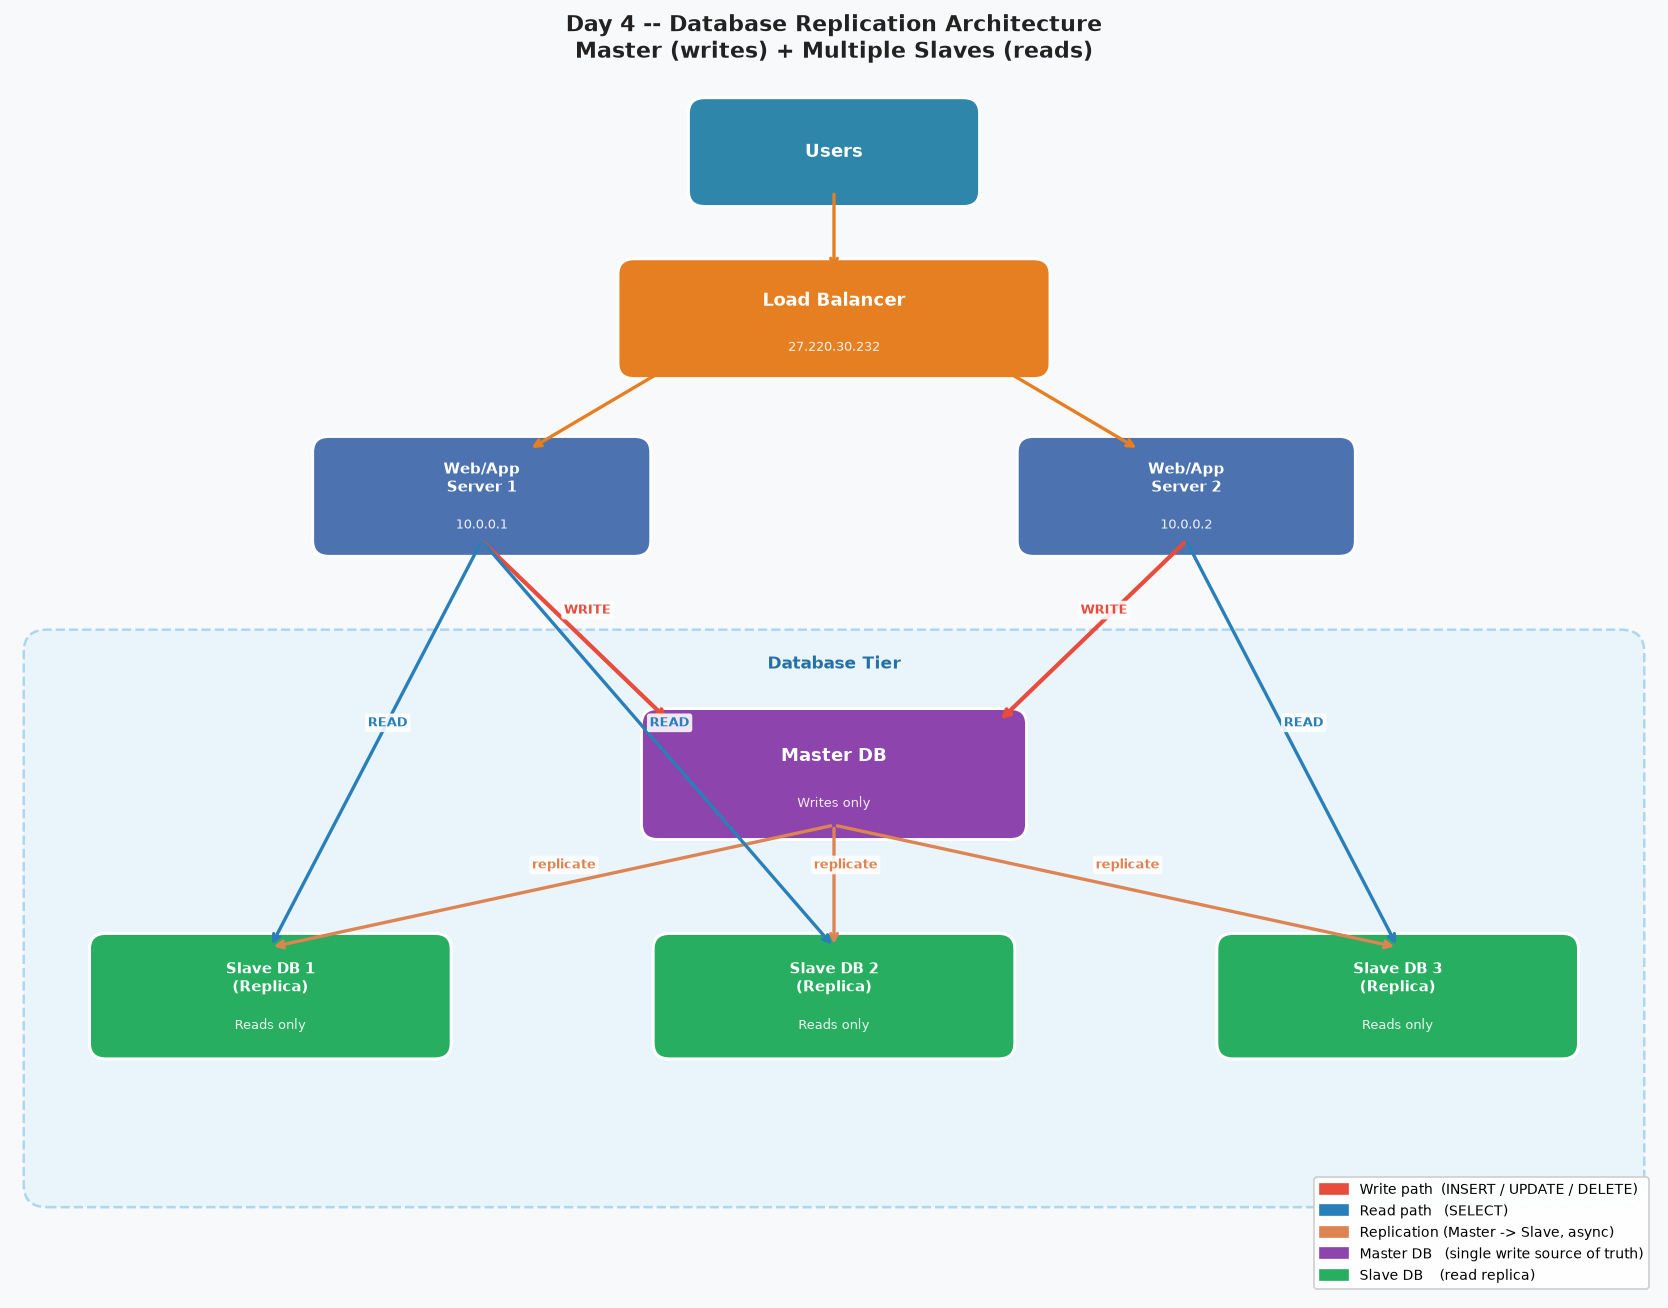

Architecture diagram complete.


In [2]:
# Full system diagram: LB + Web Servers + Master DB + 3 Slave DBs
# Shows write path (red) -> Master, read path (blue) -> Slaves

fig, ax = plt.subplots(figsize=(14, 11))
ax.set_xlim(0, 14); ax.set_ylim(0, 11)
ax.axis('off')
ax.set_facecolor(C_GRAY)
fig.patch.set_facecolor(C_GRAY)

def box(ax, x, y, w, h, label, sub='', color=C_BLUE, fs=10, tc='white'):
    r = FancyBboxPatch((x-w/2, y-h/2), w, h,
                       boxstyle='round,pad=0.14',
                       facecolor=color, edgecolor='white', lw=1.8)
    ax.add_patch(r)
    ax.text(x, y + (0.16 if sub else 0), label,
            ha='center', va='center', fontsize=fs,
            fontweight='bold', color=tc)
    if sub:
        ax.text(x, y - 0.26, sub, ha='center', va='center',
                fontsize=7.5, color=tc, alpha=0.9)

def arr(ax, x1, y1, x2, y2, label='', color='#555', lw=2.0, style='->'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle=style, color=color, lw=lw))
    if label:
        ax.text((x1+x2)/2 + 0.1, (y1+y2)/2 + 0.16, label,
                ha='center', fontsize=8, color=color, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                          alpha=0.88, lw=0))

# ── Tier 1: Users ─────────────────────────────────────────────────────────────
box(ax,  7, 10.3, 2.2, 0.7, 'Users', color=C_TEAL, fs=11)

# ── Tier 2: Load Balancer ─────────────────────────────────────────────────────
box(ax,  7,  8.8, 3.4, 0.8, 'Load Balancer', sub='27.220.30.232', color=C_LB, fs=11)
arr(ax,  7, 9.95,  7, 9.22, '', C_LB)

# ── Tier 3: Web / App Servers ─────────────────────────────────────────────────
box(ax,  4,  7.2, 2.6, 0.8, 'Web/App\nServer 1', sub='10.0.0.1', color=C_BLUE, fs=9)
box(ax, 10,  7.2, 2.6, 0.8, 'Web/App\nServer 2', sub='10.0.0.2', color=C_BLUE, fs=9)
arr(ax,  5.65, 8.4, 4.4, 7.62, '', C_LB)
arr(ax,  8.35, 8.4, 9.6, 7.62, '', C_LB)

# ── DB tier boundary ──────────────────────────────────────────────────────────
db_bg = FancyBboxPatch((0.3, 1.0), 13.4, 4.8,
                       boxstyle='round,pad=0.2',
                       facecolor='#EAF4FB', edgecolor='#AED6F1', lw=1.5,
                       linestyle='--')
ax.add_patch(db_bg)
ax.text(7, 5.65, 'Database Tier', ha='center', fontsize=10,
        fontweight='bold', color='#2471A3')

# ── Master DB ─────────────────────────────────────────────────────────────────
box(ax,  7,  4.7, 3.0, 0.9, 'Master DB',
    sub='Writes only', color=C_MASTER, fs=11)

# Write paths (red): Web servers -> Master
arr(ax,  4,  6.8,  5.6, 5.17,  'WRITE', C_WRITE, lw=2.5)
arr(ax, 10,  6.8,  8.4, 5.17,  'WRITE', C_WRITE, lw=2.5)

# ── Slave / Replica DBs ───────────────────────────────────────────────────────
slave_positions = [(2.2, 2.7), (7, 2.7), (11.8, 2.7)]
slave_labels    = ['Slave DB 1\n(Replica)', 'Slave DB 2\n(Replica)',
                   'Slave DB 3\n(Replica)']
for (sx, sy), lbl in zip(slave_positions, slave_labels):
    box(ax, sx, sy, 2.8, 0.85, lbl, sub='Reads only', color=C_SLAVE, fs=9)

# Replication arrows: Master -> Slaves (orange)
for sx, sy in slave_positions:
    arr(ax, 7, 4.24, sx, 3.14, 'replicate', C_ORANGE, lw=2.0)

# Read paths (blue): Web servers -> Slaves
arr(ax,  4, 6.8,  2.2, 3.14, 'READ', C_READ, lw=2.0)
arr(ax,  4, 6.8,  7,   3.14, 'READ', C_READ, lw=2.0)
arr(ax, 10, 6.8, 11.8, 3.14, 'READ', C_READ, lw=2.0)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_items = [
    mpatches.Patch(color=C_WRITE,  label='Write path  (INSERT / UPDATE / DELETE)'),
    mpatches.Patch(color=C_READ,   label='Read path   (SELECT)'),
    mpatches.Patch(color=C_ORANGE, label='Replication (Master -> Slave, async)'),
    mpatches.Patch(color=C_MASTER, label='Master DB   (single write source of truth)'),
    mpatches.Patch(color=C_SLAVE,  label='Slave DB    (read replica)'),
]
ax.legend(handles=legend_items, loc='lower right', fontsize=8.5,
          framealpha=0.95, edgecolor='#CCC', bbox_to_anchor=(1.0, 0.0))

ax.set_title('Day 4 -- Database Replication Architecture\n'
             'Master (writes) + Multiple Slaves (reads)',
             fontsize=13, fontweight='bold', color='#222', pad=10)
plt.tight_layout()
plt.savefig('/tmp/sd_day4_architecture.png', dpi=130, bbox_inches='tight')
plt.show()
print("Architecture diagram complete.")


### What this shows

**Red arrows (WRITE):** Both web servers send all write operations exclusively to the Master DB.  
**Blue arrows (READ):** Web servers distribute read queries across the three Slave DBs.  
**Orange arrows (replicate):** The Master continuously replicates every committed write to all three Slaves.  

The dashed boundary box marks the **Database Tier** — an isolated network segment (typically a private VPC subnet) not directly reachable from the internet.

**Why this matters:** A single database at ~5 000 QPS read limit now becomes ~20 000 QPS read capacity with three replicas — a 4× improvement with no schema changes.

## 3. Why Replication? Read/Write Ratios, Throughput & Lag

Replication is primarily a **read-scaling** strategy. Most production systems are read-heavy: social feeds are 95% reads, analytics dashboards 99%. Each replica multiplies read capacity while writes remain bottlenecked at the single master.

However, replication introduces **lag** — the delay between a write landing on the master and becoming visible on a replica. Under normal load this is 1–10 ms; under a write storm it can spike to hundreds of milliseconds.

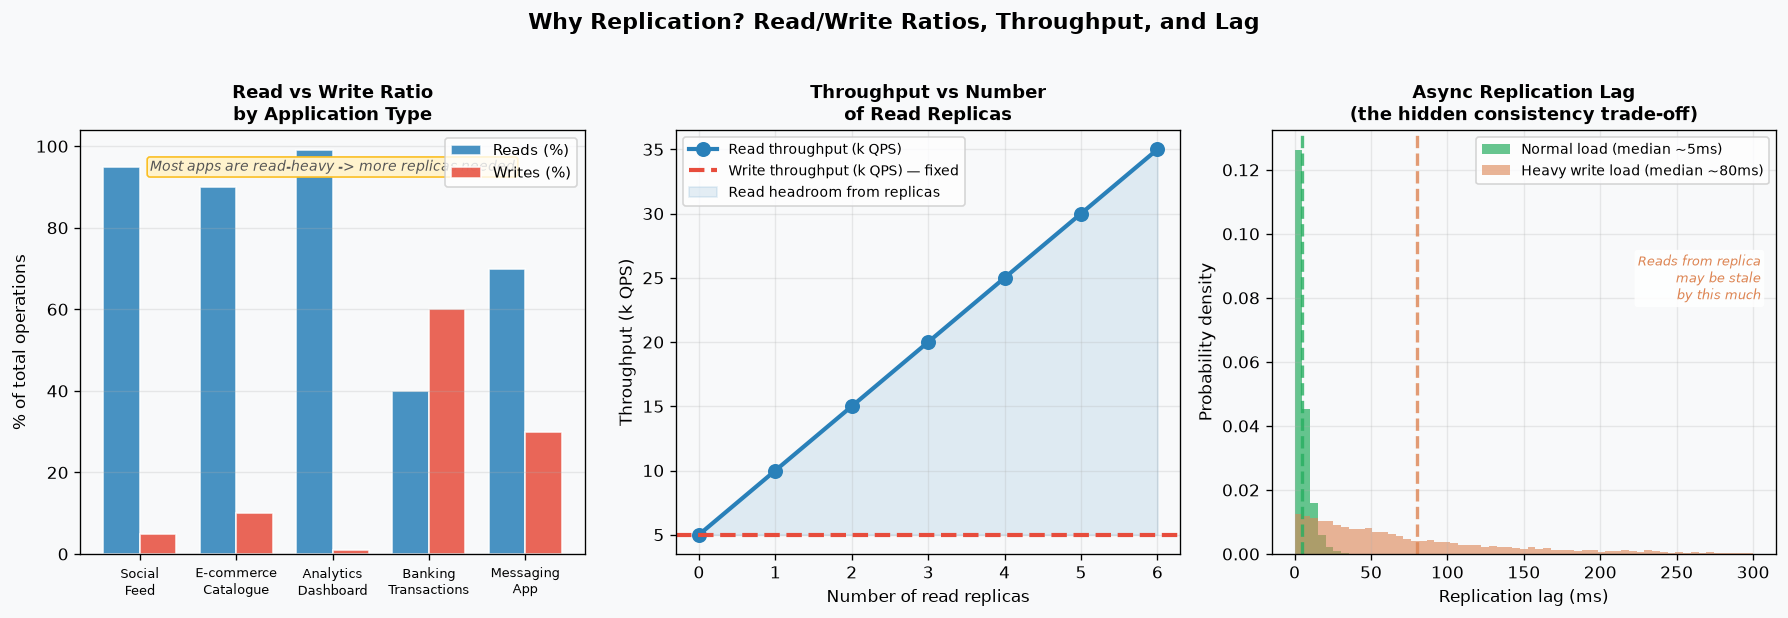

In [3]:
# Read/write ratio visualisation + why we need more slaves than masters

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor(C_GRAY)

# ── Left: typical read/write ratios by app type ───────────────────────────────
ax = axes[0]
ax.set_facecolor(C_GRAY)
apps  = ['Social\nFeed', 'E-commerce\nCatalogue', 'Analytics\nDashboard',
         'Banking\nTransactions', 'Messaging\nApp']
reads = [95, 90, 99, 40, 70]
writes = [5, 10, 1, 60, 30]
x = np.arange(len(apps))
w = 0.38
ax.bar(x - w/2, reads,  width=w, color=C_READ,  alpha=0.85,
       edgecolor='white', label='Reads (%)')
ax.bar(x + w/2, writes, width=w, color=C_WRITE, alpha=0.85,
       edgecolor='white', label='Writes (%)')
ax.set_xticks(x); ax.set_xticklabels(apps, fontsize=8)
ax.set_ylabel('% of total operations')
ax.set_title('Read vs Write Ratio\nby Application Type', fontsize=11,
             fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.25)
ax.text(0.5, 0.93, 'Most apps are read-heavy -> more replicas needed',
        ha='center', va='top', transform=ax.transAxes, fontsize=8.5,
        fontstyle='italic', color='#555',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='#FFF3CD',
                  edgecolor='#FBBF24', lw=1.0))

# ── Middle: throughput scaling with replicas ──────────────────────────────────
ax = axes[1]
ax.set_facecolor(C_GRAY)
n_replicas = np.arange(0, 7)
# Read throughput scales with replicas; write stays fixed (all go to master)
read_tput  = (n_replicas + 1) * 5000   # 5k QPS per DB node
write_tput = np.full_like(n_replicas, 5000, dtype=float)  # fixed: 1 master

ax.plot(n_replicas, read_tput/1000,  'o-', color=C_READ,  lw=2.5, ms=8,
        label='Read throughput (k QPS)')
ax.axhline(write_tput[0]/1000, color=C_WRITE, lw=2.5, linestyle='--',
           label='Write throughput (k QPS) — fixed')
ax.fill_between(n_replicas, write_tput/1000, read_tput/1000,
                alpha=0.12, color=C_READ, label='Read headroom from replicas')
ax.set_xlabel('Number of read replicas')
ax.set_ylabel('Throughput (k QPS)')
ax.set_title('Throughput vs Number\nof Read Replicas', fontsize=11,
             fontweight='bold')
ax.legend(fontsize=8.5); ax.grid(alpha=0.25)

# ── Right: replication lag distribution ───────────────────────────────────────
ax = axes[2]
ax.set_facecolor(C_GRAY)
np.random.seed(42)
# Async replication lag: typically 1-50ms, spikes under heavy write load
lag_normal = np.random.exponential(scale=5, size=5000)    # ms
lag_heavy  = np.random.exponential(scale=80, size=5000)   # ms under write storm

bins = np.linspace(0, 300, 60)
ax.hist(lag_normal, bins=bins, color=C_SLAVE, alpha=0.7, density=True,
        label='Normal load (median ~5ms)')
ax.hist(lag_heavy,  bins=bins, color=C_ORANGE, alpha=0.6, density=True,
        label='Heavy write load (median ~80ms)')
ax.axvline(5,  color=C_SLAVE,  lw=2, linestyle='--', alpha=0.8)
ax.axvline(80, color=C_ORANGE, lw=2, linestyle='--', alpha=0.8)
ax.set_xlabel('Replication lag (ms)')
ax.set_ylabel('Probability density')
ax.set_title('Async Replication Lag\n(the hidden consistency trade-off)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8.5); ax.grid(alpha=0.25)
ax.text(0.97, 0.65,
        'Reads from replica\nmay be stale\nby this much',
        ha='right', va='center', transform=ax.transAxes, fontsize=8,
        color=C_ORANGE, fontstyle='italic',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                  alpha=0.85, lw=0))

plt.suptitle('Why Replication? Read/Write Ratios, Throughput, and Lag',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/tmp/sd_day4_ratios.png', dpi=130, bbox_inches='tight')
plt.show()


### What these charts show

**Left — Read vs Write Ratio:** Most applications spend the majority of DB operations on reads. Only write-heavy workloads (banking transactions, real-time messaging) break this pattern. This ratio directly justifies adding read replicas.

**Middle — Throughput Scaling:** Read throughput grows linearly with replica count (each adds ~5 000 QPS). Write throughput stays fixed at the master's capacity regardless of how many replicas exist. The blue shaded region is the 'read headroom' gained purely from replication.

**Right — Replication Lag Distribution:** Under normal load most replication events complete in under 10 ms. During write storms (e.g. a viral event causing millions of simultaneous writes) lag spikes sharply. Applications reading from a lagging replica may see stale data — this is the **eventual consistency** trade-off.

## 4. Replication Modes: Synchronous vs Asynchronous vs Semi-Synchronous

Not all replication is equal. The mode determines the **consistency vs latency trade-off**:

| Mode | Consistency | Latency | Data Loss Risk |
|---|---|---|---|
| Synchronous | Strong | High (~10× slower) | None |
| Asynchronous | Eventual | Lowest | Possible (lag window) |
| Semi-Synchronous | Balanced | Moderate | Near-zero (1 confirmed copy) |

MySQL defaults to **asynchronous**. MySQL semi-sync plugin and PostgreSQL synchronous_commit provide the other modes.

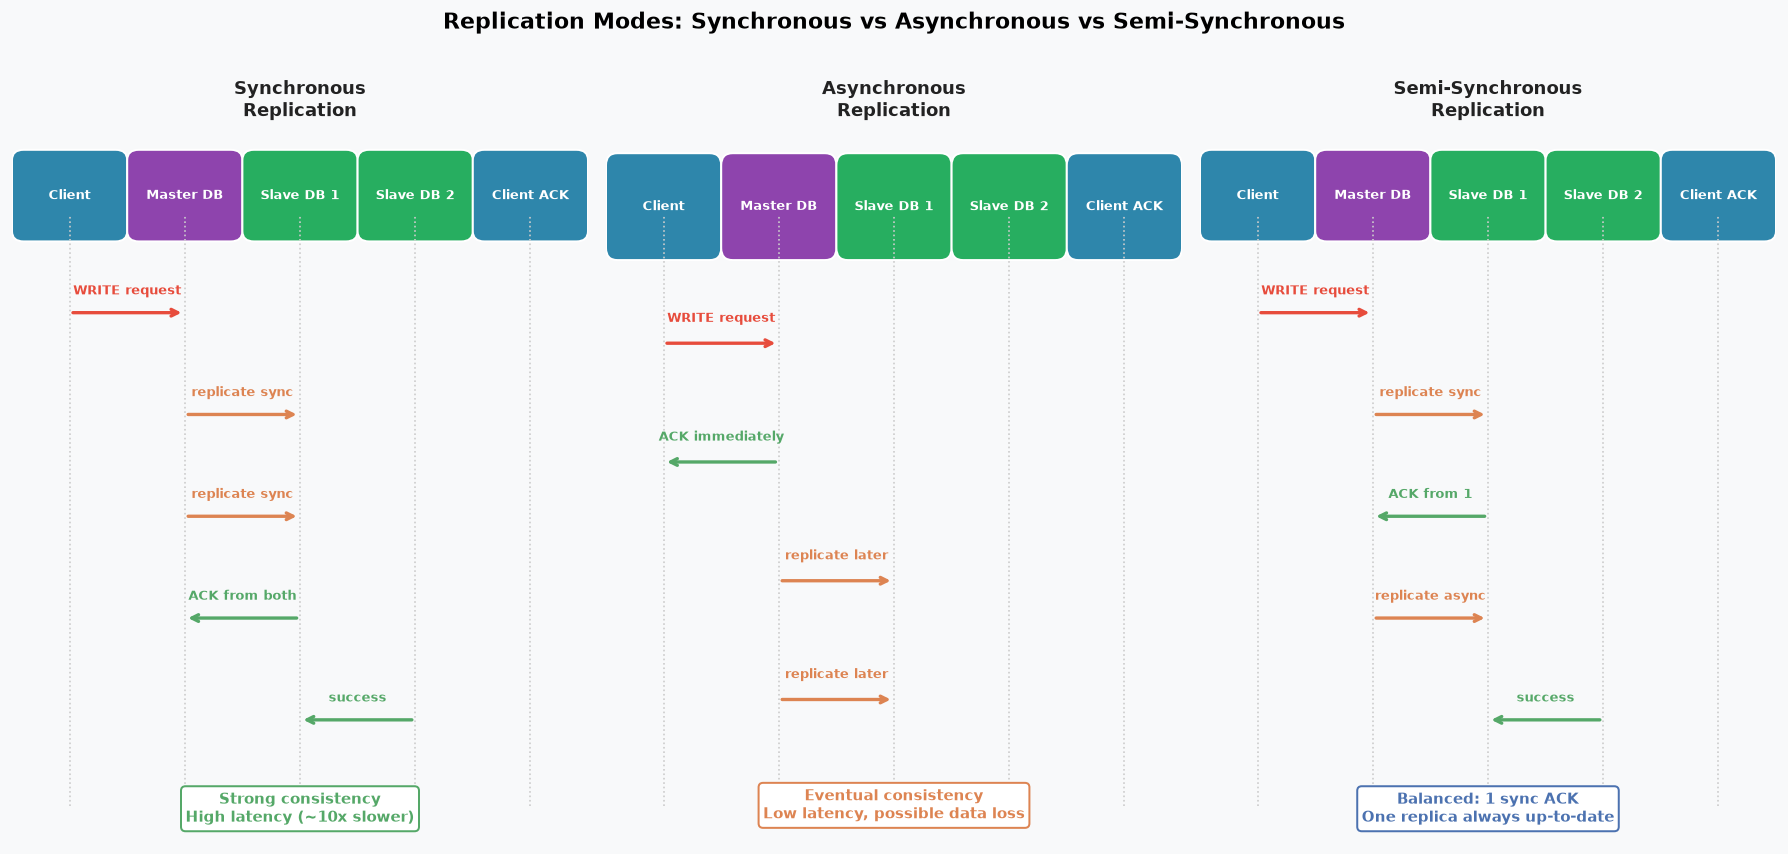

In [4]:
# Replication modes: sync vs async vs semi-sync

fig, axes = plt.subplots(1, 3, figsize=(15, 7))
fig.patch.set_facecolor(C_GRAY)
plt.suptitle('Replication Modes: Synchronous vs Asynchronous vs Semi-Synchronous',
             fontsize=13, fontweight='bold', y=1.01)

mode_data = [
    ('Synchronous\nReplication',
     ['Client', 'Master DB', 'Slave DB 1', 'Slave DB 2', 'Client ACK'],
     [
         (0, 'WRITE request',   C_WRITE),
         (1, 'replicate sync',  C_ORANGE),
         (1, 'replicate sync',  C_ORANGE),
         (2, 'ACK from both',   C_GREEN),
         (3, 'success',         C_GREEN),
     ],
     'Strong consistency\nHigh latency (~10x slower)',
     C_GREEN),

    ('Asynchronous\nReplication',
     ['Client', 'Master DB', 'Slave DB 1', 'Slave DB 2', 'Client ACK'],
     [
         (0, 'WRITE request',   C_WRITE),
         (1, 'ACK immediately', C_GREEN),
         (1, 'replicate later', C_ORANGE),
         (1, 'replicate later', C_ORANGE),
     ],
     'Eventual consistency\nLow latency, possible data loss',
     C_ORANGE),

    ('Semi-Synchronous\nReplication',
     ['Client', 'Master DB', 'Slave DB 1', 'Slave DB 2', 'Client ACK'],
     [
         (0, 'WRITE request',   C_WRITE),
         (1, 'replicate sync',  C_ORANGE),
         (2, 'ACK from 1',      C_GREEN),
         (1, 'replicate async', C_ORANGE),
         (3, 'success',         C_GREEN),
     ],
     'Balanced: 1 sync ACK\nOne replica always up-to-date',
     C_BLUE),
]

for ax, (title, actors, steps, verdict, verdict_color) in zip(axes, mode_data):
    ax.set_xlim(-0.5, len(actors) - 0.5)
    ax.set_ylim(-0.5, len(steps) + 1.5)
    ax.axis('off')
    ax.set_facecolor(C_GRAY)
    ax.set_title(title, fontsize=11, fontweight='bold', color='#222', pad=8)

    # Actor columns
    for i, actor in enumerate(actors):
        color = (C_TEAL if 'Client' in actor
                 else C_MASTER if 'Master' in actor
                 else C_SLAVE if 'Slave' in actor
                 else '#888')
        r = FancyBboxPatch((i-0.4, len(steps)+0.5), 0.8, 0.7,
                           boxstyle='round,pad=0.1',
                           facecolor=color, edgecolor='white', lw=1.2)
        ax.add_patch(r)
        ax.text(i, len(steps)+0.85, actor, ha='center', va='center',
                fontsize=7.5, fontweight='bold', color='white')
        # Lifeline
        ax.axvline(i, ymin=0.05, ymax=0.88, color='#CCC', lw=1, linestyle=':')

    # Message arrows (drawn top to bottom)
    from_pos = [0, 1, 1, 2, 3]  # default sequence
    to_pos   = [1, 2, 3, 1, 0]
    for step_i, (col_pair, msg, color) in enumerate(steps):
        y = len(steps) - step_i - 0.3
        # Use col_pair as the "from" column; derive "to" by context
        x_from = col_pair
        # Determine direction from message content
        if 'replicate' in msg:
            x_to = col_pair + 1 if col_pair + 1 < len(actors) - 1 else col_pair + 1
        elif 'ACK' in msg or 'success' in msg:
            x_to = col_pair - 1
        else:
            x_to = col_pair + 1

        x_to = max(0, min(len(actors)-1, x_to))
        ax.annotate('', xy=(x_to, y), xytext=(x_from, y),
                    arrowprops=dict(arrowstyle='->', color=color, lw=2.0))
        ax.text((x_from + x_to)/2, y + 0.18, msg, ha='center',
                fontsize=7.5, color=color, fontweight='bold')

    ax.text(len(actors)/2 - 0.5, -0.3, verdict,
            ha='center', fontsize=9, color=verdict_color, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor=verdict_color, lw=1.2))

plt.tight_layout()
plt.savefig('/tmp/sd_day4_replication_modes.png', dpi=130, bbox_inches='tight')
plt.show()


### What this shows

Each panel is a **sequence diagram** showing the message flow for one replication mode:

**Synchronous (left):** The client's write does not receive an ACK until *all* replicas have confirmed. Zero data-loss guarantee, but every write waits for the slowest replica — typically ~10× latency penalty.

**Asynchronous (middle):** Master ACKs the client immediately. Replication happens in the background. Lowest latency, highest throughput. Risk: if the master crashes before replication completes, committed transactions can be lost.

**Semi-Synchronous (right):** Master waits for at least *one* slave to confirm before ACKing the client. Remaining slaves replicate asynchronously. Balances durability (one confirmed copy exists) with performance. This is the recommended default for most production MySQL/MariaDB setups.

## 5. Failover Scenarios

Replication provides redundancy, but failover is not automatic without additional tooling. There are two fundamentally different failure scenarios:

- **Slave goes offline:** Non-critical. Traffic redistributes to healthy replicas automatically via load balancer health checks.
- **Master goes offline:** Critical. Writes are blocked until a slave is promoted to new master. Tooling like **MHA (Master High Availability)**, **Orchestrator**, or **ProxySQL** can automate this in 10–30 seconds.

> **Split-brain risk:** If the old master recovers while a new master is active, two nodes accept writes simultaneously. Fencing (STONITH) or VIP promotion prevents this.

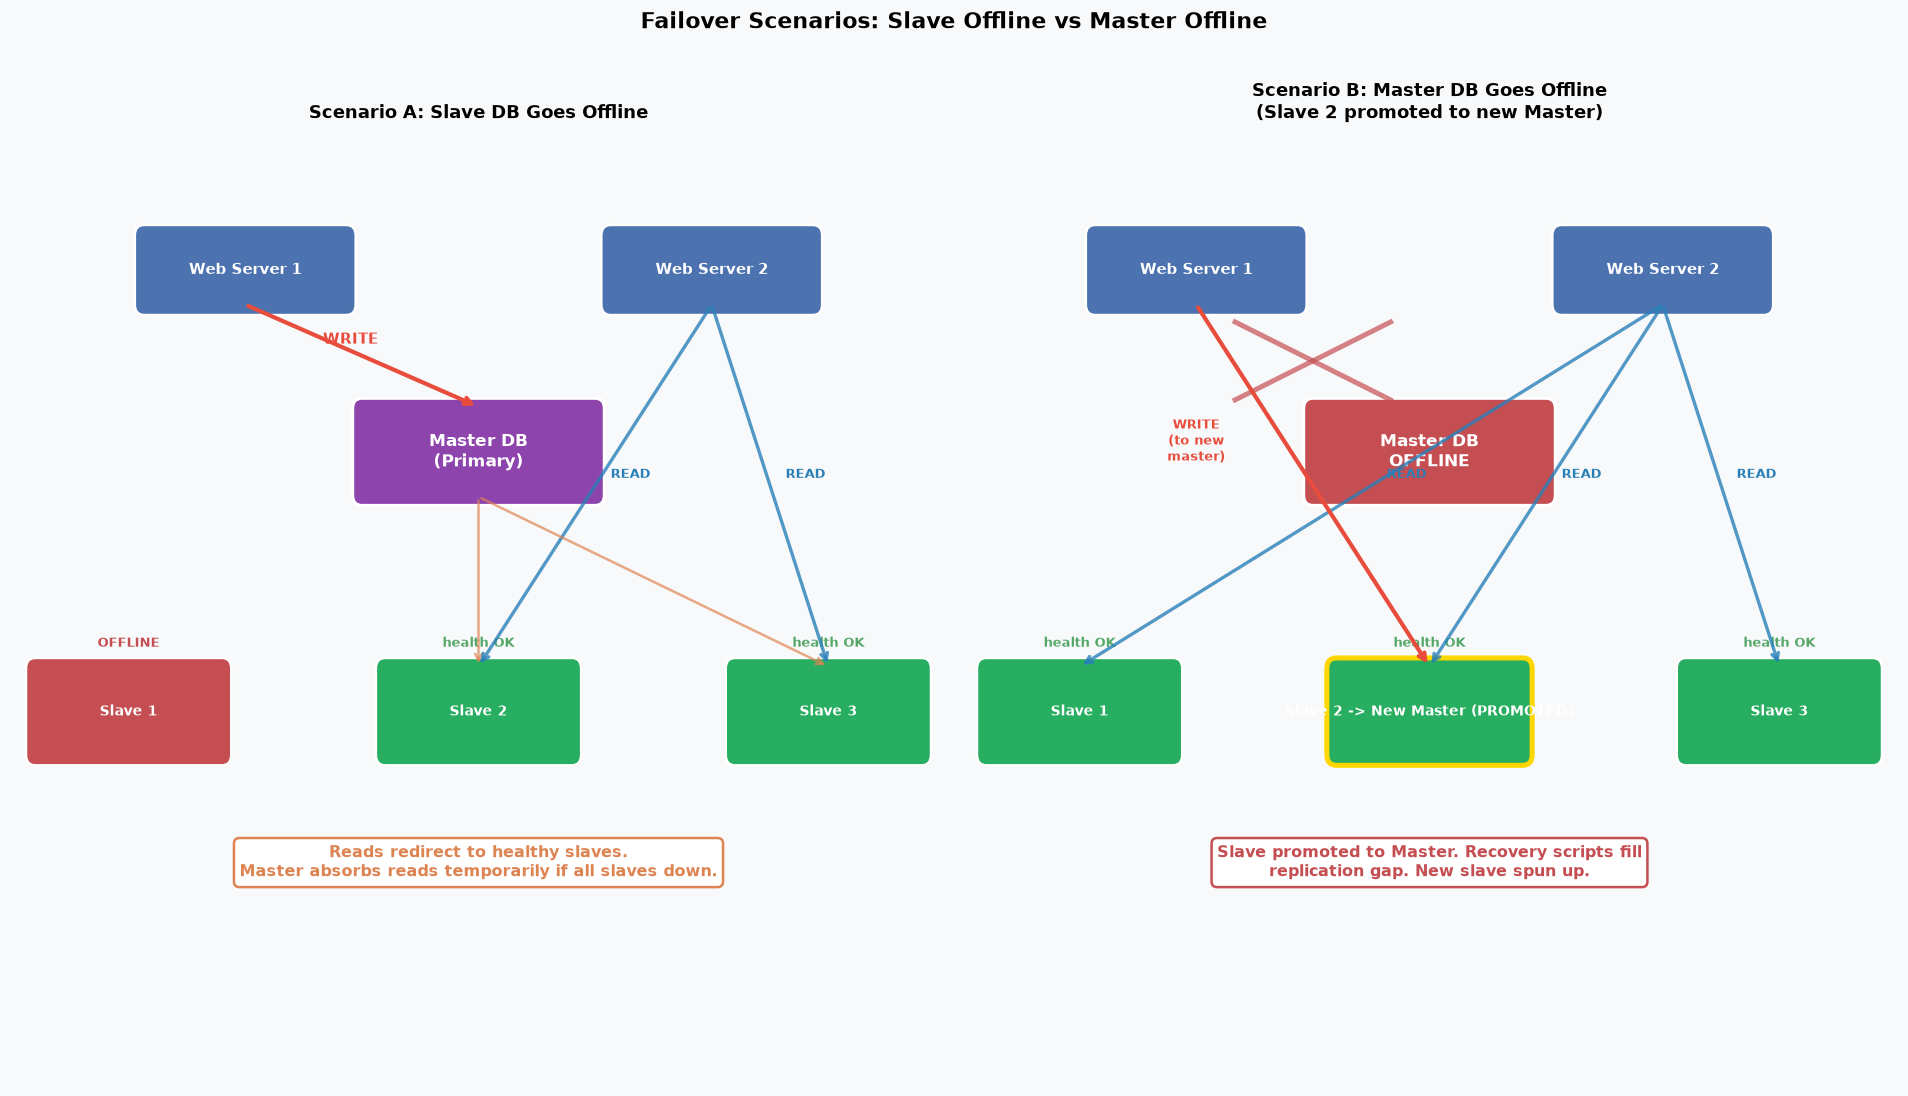

In [5]:
# Failover scenarios: Slave offline vs Master offline

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
fig.patch.set_facecolor(C_GRAY)
plt.suptitle('Failover Scenarios: Slave Offline vs Master Offline',
             fontsize=13, fontweight='bold', y=1.01)

def draw_db_cluster(ax, title, master_active, slaves,
                    read_target, write_target, note, note_color):
    """
    slaves: list of (label, active) tuples
    read_target: index into slaves that receives reads (or 'master')
    write_target: 'master' or slave index for promoted master
    """
    ax.set_xlim(0, 12); ax.set_ylim(0, 11)
    ax.axis('off'); ax.set_facecolor(C_GRAY)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)

    # Web servers (simplified)
    for xi, lbl in [(3, 'Web Server 1'), (9, 'Web Server 2')]:
        r = FancyBboxPatch((xi-1.3, 9.0), 2.6, 0.8,
                           boxstyle='round,pad=0.12',
                           facecolor=C_BLUE, edgecolor='white', lw=1.5)
        ax.add_patch(r)
        ax.text(xi, 9.4, lbl, ha='center', va='center',
                fontsize=9, fontweight='bold', color='white')

    # Master DB
    m_color = C_MASTER if master_active else C_RED
    m_label = 'Master DB\n(Primary)' if master_active else 'Master DB\nOFFLINE'
    r = FancyBboxPatch((4.5, 6.8), 3.0, 1.0,
                       boxstyle='round,pad=0.12',
                       facecolor=m_color, edgecolor='white', lw=2.0)
    ax.add_patch(r)
    ax.text(6.0, 7.3, m_label, ha='center', va='center',
            fontsize=10, fontweight='bold', color='white')

    # Write arrow to master (or crossed if offline)
    if master_active:
        ax.annotate('', xy=(6.0, 7.82), xytext=(3, 9.0),
                    arrowprops=dict(arrowstyle='->', color=C_WRITE, lw=2.5))
        ax.text(4.0, 8.55, 'WRITE', fontsize=9, color=C_WRITE, fontweight='bold')
    else:
        # X over write arrow
        ax.plot([3.5, 5.5], [8.8, 7.9], color=C_RED, lw=3, alpha=0.7)
        ax.plot([3.5, 5.5], [7.9, 8.8], color=C_RED, lw=3, alpha=0.7)

    # Slave DBs
    n = len(slaves)
    xs = np.linspace(1.5, 10.5, n)
    for j, ((lbl, active), sx) in enumerate(zip(slaves, xs)):
        s_color = C_SLAVE if active else C_RED
        border  = '#FFD700' if (write_target == j) else 'white'
        border_lw = 3.0 if (write_target == j) else 1.5
        r = FancyBboxPatch((sx-1.2, 3.8), 2.4, 1.0,
                           boxstyle='round,pad=0.12',
                           facecolor=s_color, edgecolor=border, lw=border_lw)
        ax.add_patch(r)
        promoted = ' (PROMOTED)' if write_target == j else ''
        ax.text(sx, 4.3, lbl + promoted, ha='center', va='center',
                fontsize=8.5, fontweight='bold', color='white')
        ax.text(sx, 5.05, 'health OK' if active else 'OFFLINE',
                ha='center', fontsize=7.5, fontweight='bold',
                color=C_GREEN if active else C_RED)

        # Replication arrow from master (only if both active)
        if master_active and active:
            ax.annotate('', xy=(sx, 4.82), xytext=(6.0, 6.78),
                        arrowprops=dict(arrowstyle='->', color=C_ORANGE,
                                        lw=1.5, alpha=0.7))

        # Read arrow from web servers to healthy slaves
        if active and (read_target == j or read_target == 'all'):
            ax.annotate('', xy=(sx, 4.82), xytext=(9, 9.0),
                        arrowprops=dict(arrowstyle='->', color=C_READ,
                                        lw=2.0, alpha=0.8))
            ax.text((sx+9)/2 + 0.2, 7.0, 'READ', fontsize=8,
                    color=C_READ, fontweight='bold')

    # Write arrow to promoted slave
    if not master_active and isinstance(write_target, int):
        sx = xs[write_target]
        ax.annotate('', xy=(sx, 4.82), xytext=(3, 9.0),
                    arrowprops=dict(arrowstyle='->', color=C_WRITE, lw=2.5))
        ax.text(3.0, 7.2, 'WRITE\n(to new\nmaster)',
                ha='center', fontsize=8, color=C_WRITE, fontweight='bold')

    # Note
    ax.text(6.0, 2.4, note, ha='center', fontsize=9.5,
            color=note_color, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                      edgecolor=note_color, lw=1.5))

# ── Scenario 1: Slave 1 goes offline ─────────────────────────────────────────
draw_db_cluster(
    axes[0],
    title='Scenario A: Slave DB Goes Offline',
    master_active=True,
    slaves=[('Slave 1', False), ('Slave 2', True), ('Slave 3', True)],
    read_target='all',
    write_target='master',
    note='Reads redirect to healthy slaves.\nMaster absorbs reads temporarily if all slaves down.',
    note_color=C_ORANGE,
)

# ── Scenario 2: Master goes offline -> Slave 2 promoted ──────────────────────
draw_db_cluster(
    axes[1],
    title='Scenario B: Master DB Goes Offline\n(Slave 2 promoted to new Master)',
    master_active=False,
    slaves=[('Slave 1', True), ('Slave 2 -> New Master', True), ('Slave 3', True)],
    read_target='all',
    write_target=1,   # slave index 1 promoted
    note='Slave promoted to Master. Recovery scripts fill\nreplication gap. New slave spun up.',
    note_color=C_RED,
)

plt.tight_layout()
plt.savefig('/tmp/sd_day4_failover.png', dpi=130, bbox_inches='tight')
plt.show()


### What these diagrams show

**Scenario A (left) — Slave Offline:** Slave 1 (red) is down. The load balancer's health check detects the failure and stops routing reads to it. Slaves 2 and 3 absorb the extra read load. Master continues receiving writes normally. The system degrades gracefully; no data is lost.

**Scenario B (right) — Master Offline:** The Master DB (red) crashes. Writes are halted. Slave 2 (highlighted in gold border) is elected the new Master via the promotion process — it receives a new WRITE path. A recovery script fills any replication gap (binlog replay). A new slave is eventually provisioned to restore the replica count.

**Key numbers:** With automated tooling, master failover completes in 10–30 seconds. Without tooling, manual failover can take 5–30 minutes of downtime.

## 6. Advantages, Trade-offs & Cost Analysis

Replication is not free — each replica costs hardware, storage, network I/O, and operational overhead. The question is whether the benefit (read scale + availability) justifies the cost at a given traffic level.

**When to add replicas:**
- Read QPS exceeds 70% of master capacity
- 99%+ read availability required (single DB cannot tolerate maintenance windows)
- Geo-distributed users needing low-latency local reads

**When replication is NOT enough:**
- Write throughput exceeds master capacity → need sharding or CQRS
- Strong consistency required for all reads → synchronous replication or single-node

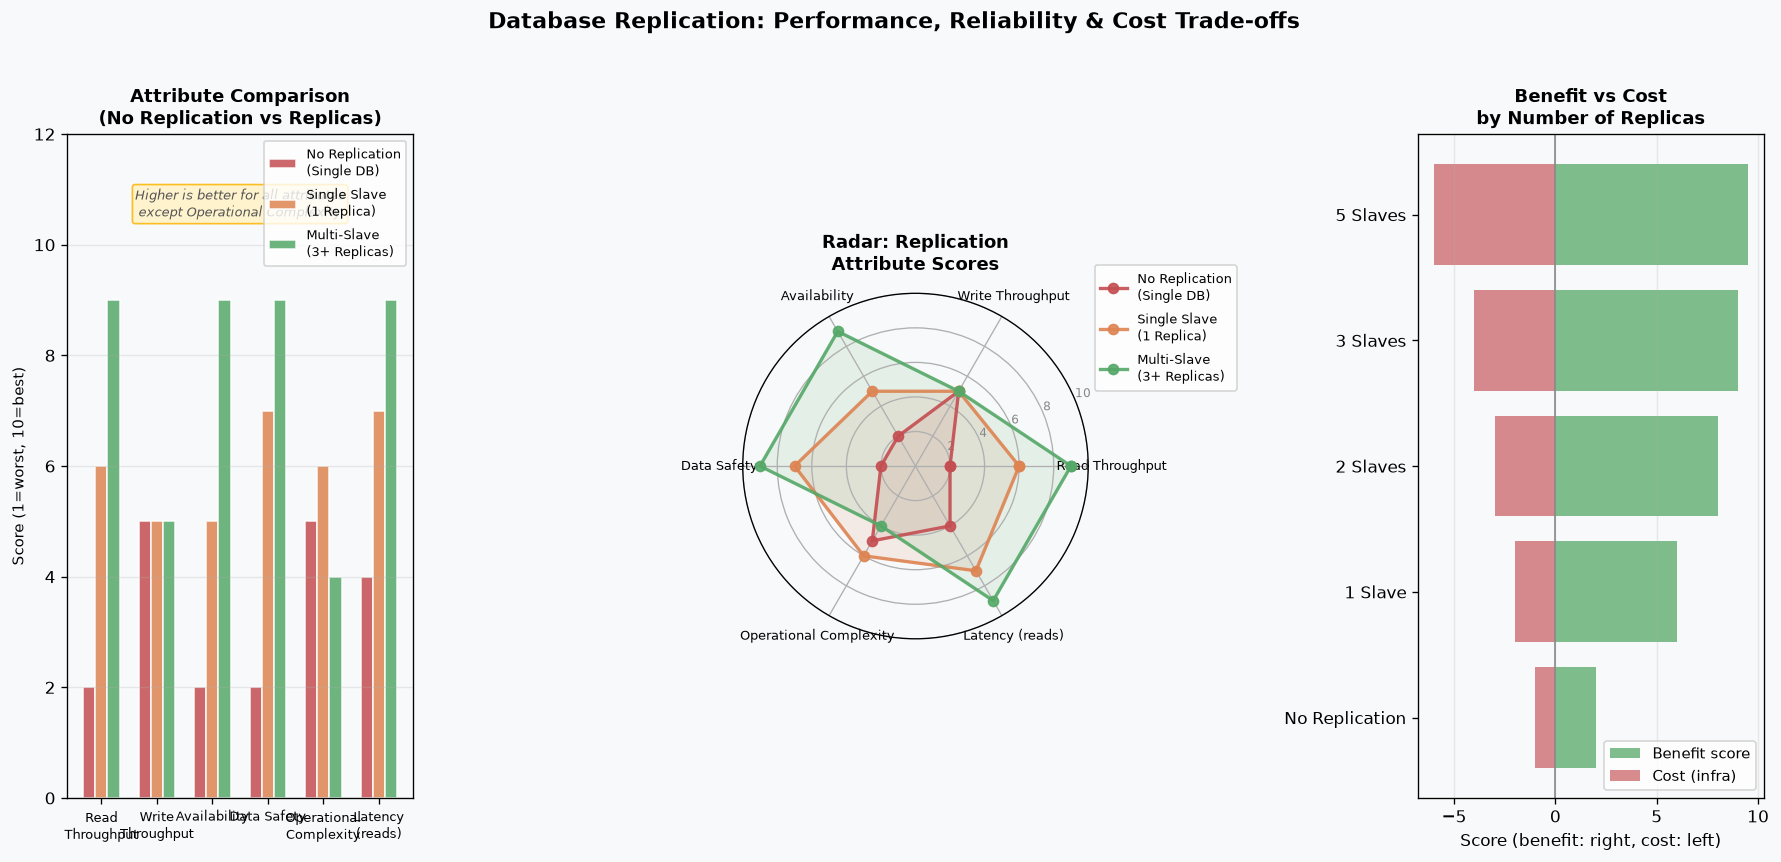

In [6]:
# Advantages comparison chart: no replication vs single slave vs multi-slave

fig, axes = plt.subplots(1, 3, figsize=(15, 7))
fig.patch.set_facecolor(C_GRAY)

categories = ['Read\nThroughput', 'Write\nThroughput', 'Availability', 'Data Safety',
              'Operational\nComplexity', 'Latency\n(reads)']

scores = {
    'No Replication\n(Single DB)':    [2, 5, 2, 2, 5, 4],
    'Single Slave\n(1 Replica)':      [6, 5, 5, 7, 6, 7],
    'Multi-Slave\n(3+ Replicas)':     [9, 5, 9, 9, 4, 9],
}
colors_map = {
    'No Replication\n(Single DB)':  C_RED,
    'Single Slave\n(1 Replica)':    C_ORANGE,
    'Multi-Slave\n(3+ Replicas)':   C_GREEN,
}

# Panel A: bar comparison across categories
ax = axes[0]
ax.set_facecolor(C_GRAY)
x = np.arange(len(categories)); w = 0.22
offsets = [-1, 0, 1]
for (label, vals), offset in zip(scores.items(), offsets):
    bars = ax.bar(x + offset*w, vals, width=w, color=colors_map[label],
                  edgecolor='white', alpha=0.85, label=label)
ax.set_xticks(x); ax.set_xticklabels(categories, fontsize=8)
ax.set_ylabel('Score (1=worst, 10=best)', fontsize=9)
ax.set_title('Attribute Comparison\n(No Replication vs Replicas)', fontsize=11,
             fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
ax.grid(axis='y', alpha=0.25)
ax.set_ylim(0, 12)
ax.text(0.5, 0.92, 'Higher is better for all attributes\nexcept Operational Complexity',
        ha='center', va='top', transform=ax.transAxes, fontsize=8,
        fontstyle='italic', color='#555',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='#FFF3CD',
                  edgecolor='#FBBF24', lw=1.0))

# Panel B: radar / polar chart (spider chart)
ax2 = axes[1]
ax2.remove()
ax2 = fig.add_subplot(1, 3, 2, polar=True)
ax2.set_facecolor(C_GRAY)

N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

for label, vals in scores.items():
    vals_closed = vals + vals[:1]
    ax2.plot(angles, vals_closed, 'o-', lw=2.0, color=colors_map[label],
             label=label, alpha=0.9)
    ax2.fill(angles, vals_closed, alpha=0.12, color=colors_map[label])

clean_cats = [c.replace('\n', ' ') for c in categories]
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(clean_cats, fontsize=8)
ax2.set_ylim(0, 10)
ax2.set_yticks([2, 4, 6, 8, 10])
ax2.set_yticklabels(['2','4','6','8','10'], fontsize=7, color='#888')
ax2.set_title('Radar: Replication\nAttribute Scores', fontsize=11,
              fontweight='bold', pad=14)
ax2.legend(loc='upper right', bbox_to_anchor=(1.45, 1.1), fontsize=8)

# Panel C: Cost vs benefit horizontal bars
ax = axes[2]
ax.set_facecolor(C_GRAY)
configs  = ['No Replication', '1 Slave', '2 Slaves', '3 Slaves', '5 Slaves']
benefit  = [2, 6, 8, 9, 9.5]  # read scale + HA
hw_cost  = [1, 2, 3, 4, 6]    # relative infra cost
ax.barh(configs, benefit, color=C_GREEN, alpha=0.75, label='Benefit score')
ax.barh(configs, [-c for c in hw_cost], color=C_RED, alpha=0.65, label='Cost (infra)')
ax.axvline(0, color='#888', lw=1)
ax.set_xlabel('Score (benefit: right, cost: left)')
ax.set_title('Benefit vs Cost\nby Number of Replicas', fontsize=11,
             fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.25)

plt.suptitle('Database Replication: Performance, Reliability & Cost Trade-offs',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/tmp/sd_day4_advantages.png', dpi=130, bbox_inches='tight')
plt.show()


### What these charts show

**Left — Attribute Comparison:** Grouped bars compare No Replication, Single Slave, and Multi-Slave across six dimensions. Multi-slave wins on read throughput, availability, and data safety. The only dimension where it scores lower is operational complexity.

**Middle — Radar Chart:** The spider diagram makes trade-offs visible at a glance. Multi-slave (green) dominates in 4 of 6 dimensions. No replication (red) wins only on simplicity.

**Right — Benefit vs Cost:** As replicas are added the benefit (read scale + HA) grows quickly at first then plateaus. The infra cost grows linearly. The optimal operating point for most systems is **2–3 replicas** — beyond that, marginal gains diminish while costs compound. Beyond 5 replicas, sharding typically offers better economics.

## 7. Evolution: Day 1 → Day 2 → Day 3 → Day 4

Each day in this series adds one capability to the architecture. By Day 4 we have a production-grade setup that handles read scale, high availability at every tier, and graceful failover — with no single point of failure remaining in the web or database layers.

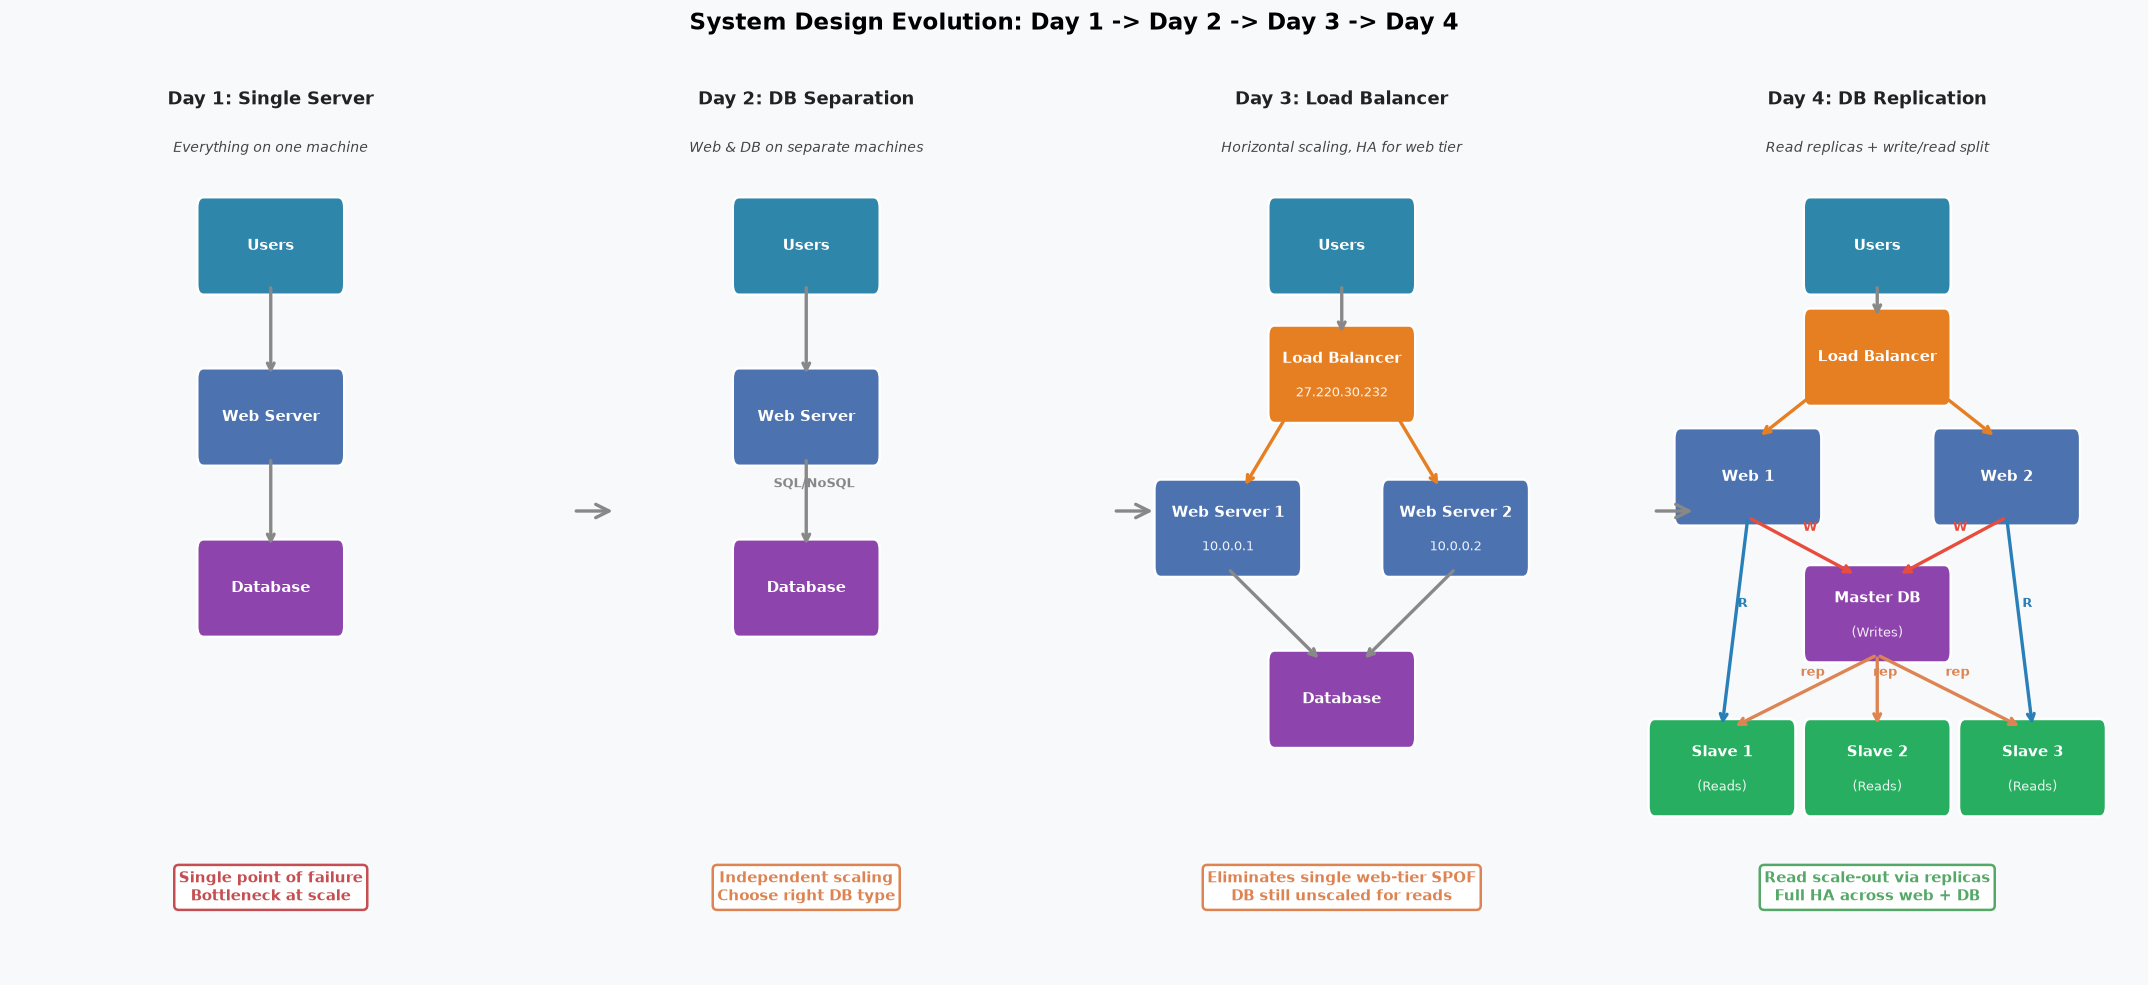

In [7]:
# Evolution diagram: Day 1 (single server) -> Day 2 (DB separation)
# -> Day 3 (Load Balancer) -> Day 4 (DB Replication)

fig, axes = plt.subplots(1, 4, figsize=(18, 8))
fig.patch.set_facecolor(C_GRAY)

def small_arch(ax, title, nodes, edges, note, note_color, subtitle=''):
    ax.set_xlim(0, 10); ax.set_ylim(0, 10)
    ax.axis('off'); ax.set_facecolor(C_GRAY)
    ax.set_title(title, fontsize=11, fontweight='bold', color='#222', pad=8)
    if subtitle:
        ax.text(5, 9.6, subtitle, ha='center', fontsize=8.5,
                color='#444', fontstyle='italic')

    for (x, y, label, color) in nodes:
        r = FancyBboxPatch((x-1.3, y-0.45), 2.6, 0.9,
                           boxstyle='round,pad=0.12',
                           facecolor=color, edgecolor='white', lw=1.5)
        ax.add_patch(r)
        lines = label.split('\n')
        if len(lines) == 1:
            ax.text(x, y, label, ha='center', va='center',
                    fontsize=9, fontweight='bold', color='white')
        else:
            ax.text(x, y+0.18, lines[0], ha='center', va='center',
                    fontsize=9, fontweight='bold', color='white')
            ax.text(x, y-0.22, lines[1], ha='center', va='center',
                    fontsize=7.5, color='white', alpha=0.9)

    for (x1, y1, x2, y2, lbl, ec) in edges:
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', color=ec, lw=2.0))
        if lbl:
            ax.text((x1+x2)/2+0.15, (y1+y2)/2+0.18, lbl,
                    ha='center', fontsize=7.5, color=ec, fontweight='bold')

    ax.text(5, 0.85, note, ha='center', fontsize=9,
            color=note_color, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor=note_color, lw=1.5))

# ── Day 1: Single server ───────────────────────────────────────────────────────
small_arch(axes[0], 'Day 1: Single Server', subtitle='Everything on one machine',
    nodes=[
        (5, 8.5, 'Users', C_TEAL),
        (5, 6.5, 'Web Server', C_BLUE),
        (5, 4.5, 'Database', C_MASTER),
    ],
    edges=[
        (5, 8.05, 5, 6.97, '', '#888'),
        (5, 6.03, 5, 4.97, '', '#888'),
    ],
    note='Single point of failure\nBottleneck at scale',
    note_color=C_RED)

# ── Day 2: DB separation ──────────────────────────────────────────────────────
small_arch(axes[1], 'Day 2: DB Separation', subtitle='Web & DB on separate machines',
    nodes=[
        (5, 8.5, 'Users', C_TEAL),
        (5, 6.5, 'Web Server', C_BLUE),
        (5, 4.5, 'Database', C_MASTER),
    ],
    edges=[
        (5, 8.05, 5, 6.97, '', '#888'),
        (5, 6.03, 5, 4.97, 'SQL/NoSQL', '#888'),
    ],
    note='Independent scaling\nChoose right DB type',
    note_color=C_ORANGE)

# ── Day 3: Load Balancer ──────────────────────────────────────────────────────
small_arch(axes[2], 'Day 3: Load Balancer', subtitle='Horizontal scaling, HA for web tier',
    nodes=[
        (5,   8.5,  'Users', C_TEAL),
        (5,   7.0,  'Load Balancer\n27.220.30.232', C_LB),
        (2.8, 5.2,  'Web Server 1\n10.0.0.1', C_BLUE),
        (7.2, 5.2,  'Web Server 2\n10.0.0.2', C_BLUE),
        (5,   3.2,  'Database', C_MASTER),
    ],
    edges=[
        (5, 8.05, 5, 7.45, '', '#888'),
        (4.0, 6.58, 3.1, 5.67, '', C_LB),
        (6.0, 6.58, 6.9, 5.67, '', C_LB),
        (2.8, 4.73, 4.6, 3.65, '', '#888'),
        (7.2, 4.73, 5.4, 3.65, '', '#888'),
    ],
    note='Eliminates single web-tier SPOF\nDB still unscaled for reads',
    note_color=C_ORANGE)

# ── Day 4: DB Replication ─────────────────────────────────────────────────────
small_arch(axes[3], 'Day 4: DB Replication', subtitle='Read replicas + write/read split',
    nodes=[
        (5,   8.5, 'Users', C_TEAL),
        (5,   7.2, 'Load Balancer', C_LB),
        (2.5, 5.8, 'Web 1', C_BLUE),
        (7.5, 5.8, 'Web 2', C_BLUE),
        (5,   4.2, 'Master DB\n(Writes)', C_MASTER),
        (2.0, 2.4, 'Slave 1\n(Reads)', C_SLAVE),
        (5.0, 2.4, 'Slave 2\n(Reads)', C_SLAVE),
        (8.0, 2.4, 'Slave 3\n(Reads)', C_SLAVE),
    ],
    edges=[
        (5, 8.05, 5, 7.65, '', '#888'),
        (4.0, 6.88, 2.7, 6.26, '', C_LB),
        (6.0, 6.88, 7.3, 6.26, '', C_LB),
        (2.5, 5.33, 4.6, 4.65, 'W', C_WRITE),
        (7.5, 5.33, 5.4, 4.65, 'W', C_WRITE),
        (5, 3.72, 2.2, 2.87, 'rep', C_ORANGE),
        (5, 3.72, 5,   2.87, 'rep', C_ORANGE),
        (5, 3.72, 7.8, 2.87, 'rep', C_ORANGE),
        (2.5, 5.33, 2.0, 2.87, 'R', C_READ),
        (7.5, 5.33, 8.0, 2.87, 'R', C_READ),
    ],
    note='Read scale-out via replicas\nFull HA across web + DB',
    note_color=C_GREEN)

# Connector arrows between panels
for xf in [0.268, 0.518, 0.768]:
    fig.add_artist(
        plt.matplotlib.patches.FancyArrowPatch(
            (xf, 0.5), (xf + 0.02, 0.5),
            transform=fig.transFigure, arrowstyle='->', color='#888', lw=2.0,
            mutation_scale=20
        )
    )

plt.suptitle('System Design Evolution: Day 1 -> Day 2 -> Day 3 -> Day 4',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/tmp/sd_day4_evolution.png', dpi=130, bbox_inches='tight')
plt.show()


### What this shows

**Day 1 → Single Server:** One machine handles web serving, application logic, and the database. Simple to operate, but one process saturating CPU or disk takes the entire site down.

**Day 2 → DB Separation:** Web and database run on dedicated hardware. Resources no longer compete. Each tier can be sized independently. SQL/NoSQL choice is now possible.

**Day 3 → Load Balancer:** A second web server is added behind a load balancer. The web tier is now horizontally scalable and tolerant of a single server failure. The database remains the last single point of failure.

**Day 4 → DB Replication:** The database single point of failure is eliminated. Read traffic is distributed across three replicas. The master handles only writes. Failover is automated via promotion scripts. The system can now serve millions of read requests/day.

## 8. Day 4 Scorecard

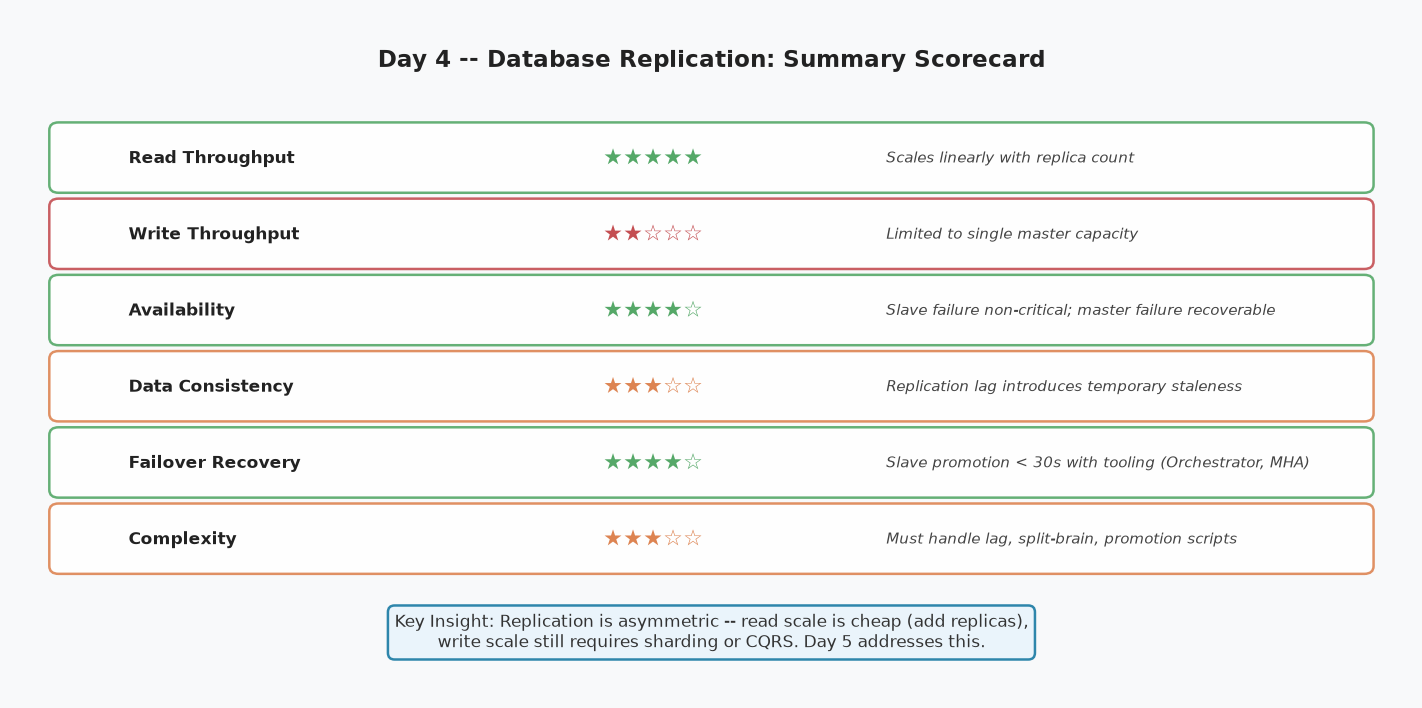

Day 4 complete.


In [8]:
# Day 4 Scorecard

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(0, 12); ax.set_ylim(0, 7)
ax.axis('off')
ax.set_facecolor(C_GRAY)
fig.patch.set_facecolor(C_GRAY)

ax.text(6, 6.5, 'Day 4 -- Database Replication: Summary Scorecard',
        ha='center', va='center', fontsize=14, fontweight='bold', color='#222')

metrics = [
    ('Read Throughput',    '★★★★★', C_GREEN,   'Scales linearly with replica count'),
    ('Write Throughput',   '★★☆☆☆', C_RED,     'Limited to single master capacity'),
    ('Availability',       '★★★★☆', C_GREEN,   'Slave failure non-critical; master failure recoverable'),
    ('Data Consistency',   '★★★☆☆', C_ORANGE,  'Replication lag introduces temporary staleness'),
    ('Failover Recovery',  '★★★★☆', C_GREEN,   'Slave promotion < 30s with tooling (Orchestrator, MHA)'),
    ('Complexity',         '★★★☆☆', C_ORANGE,  'Must handle lag, split-brain, promotion scripts'),
]

y_start = 5.5
for i, (metric, stars, color, detail) in enumerate(metrics):
    y = y_start - i * 0.78
    r = FancyBboxPatch((0.4, y-0.27), 11.2, 0.56,
                       boxstyle='round,pad=0.08',
                       facecolor='white', edgecolor=color, lw=1.5, alpha=0.9)
    ax.add_patch(r)
    ax.text(1.0, y, metric, ha='left', va='center',
            fontsize=10, fontweight='bold', color='#222')
    ax.text(5.5, y, stars, ha='center', va='center',
            fontsize=13, color=color)
    ax.text(7.5, y, detail, ha='left', va='center',
            fontsize=9, color='#444', fontstyle='italic')

# Bottom: key takeaways
ax.text(6, 0.65,
        'Key Insight: Replication is asymmetric -- read scale is cheap (add replicas),\n'
        'write scale still requires sharding or CQRS. Day 5 addresses this.',
        ha='center', va='center', fontsize=10, color='#333',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#EAF4FB',
                  edgecolor=C_TEAL, lw=1.5))

plt.tight_layout()
plt.savefig('/tmp/sd_day4_scorecard.png', dpi=130, bbox_inches='tight')
plt.show()
print("Day 4 complete.")


### What this shows

A six-dimension scorecard for the Day 4 architecture:

- **Read Throughput (5/5):** Adds ~5 000 QPS per replica — linear scaling.
- **Write Throughput (2/5):** Still bottlenecked at one master. Horizontal write scale requires sharding (Day N+2).
- **Availability (4/5):** Slave failure is transparent; master failover is ~30 s with tooling.
- **Data Consistency (3/5):** Async replication means stale reads during lag windows are possible.
- **Failover Recovery (4/5):** Automated tooling (Orchestrator / MHA) makes promotion fast and reliable.
- **Complexity (3/5):** Must manage binlog positions, promotion scripts, split-brain prevention, and monitoring for lag.

**Bottom line:** Replication is the right next step after load balancing. It solves read scale and DB availability at low cost. Write scale is the next challenge — addressed by sharding.

## AWS Production Notes

> Based on the AWS Well-Architected Framework and AWS official documentation.

---

### Critical Corrections

| Claim in This Notebook | Correction |
|---|---|
| 'Master failover completes in 10–30s with MHA or Orchestrator' | **MHA and Orchestrator are self-managed MySQL tools — irrelevant for RDS/Aurora.** AWS manages failover automatically. RDS Multi-AZ (single standby): 60–120s. RDS Multi-AZ cluster (two readable standbys): **< 35s**. |
| Semi-synchronous replication as 'recommended default for most production MySQL' | This applies only to self-managed MySQL. **RDS Multi-AZ uses AWS-managed fully synchronous replication** — there is no semi-sync plugin configuration in RDS. |
| Replication lag '1–10ms under normal load' | CloudWatch `ReplicaLag` for RDS reports **Seconds_Behind_Master in seconds, not milliseconds**. Aurora replica lag is typically under 100ms but uses shared storage — fundamentally different from binlog replication. |
| 'Read throughput scales linearly, ~5,000 QPS per replica node' | This number has no AWS basis. Actual read throughput per replica scales with the **DB instance class** (vCPU/memory). Hard-coding 5,000 QPS causes incorrect capacity estimates. |
| Application code routing reads to individual named slave replicas | In Aurora, connect applications to the **cluster reader endpoint** — never to individual replica instance endpoints. The reader endpoint auto-load-balances across all healthy Aurora Replicas. |

---

### RDS Multi-AZ vs Read Replicas: The Most Common AWS Mistake

| Feature | RDS Multi-AZ (HA) | Read Replica (Read Scale) |
|---|---|---|
| Replication type | **Synchronous** | **Asynchronous** |
| Can serve reads? | **No** — standby only | **Yes** — serves read traffic |
| Purpose | **High availability / failover** | **Read scaling** |
| Failover | **Automatic** (60–120s) | Manual promotion only |
| AWS documentation | *'Not a scaling solution for read-only scenarios'* | *'Use for read scaling'* |

> **Multi-AZ DB cluster** (since 2022): ONE writer + TWO readable standbys. Failover < 35s. Both HA and read scaling from a single deployment.

---

### Aurora vs RDS Replication Architecture

| Aspect | RDS (MySQL/PostgreSQL) | Amazon Aurora |
|---|---|---|
| Replication mechanism | Binary log (binlog) | **Shared distributed storage** (6-way across 3 AZs) |
| How replicas work | Data copied between instances | Replicas read from **same cluster volume** — no data copying |
| Replication lag | 1ms–100s+ (binlog transfer) | Typically **< 100ms** (storage-level) |
| Max replicas | 5 (RDS) | **15 Aurora Replicas** |
| Cross-region | Cross-region Read Replicas | **Aurora Global Database** (< 1s lag, 5 regions) |
| Max storage | 64 TiB (RDS) | **128 TiB** (auto-scaling) |

---

### AWS Services for This Day

| Service | What It Replaces | Why |
|---|---|---|
| **RDS Multi-AZ** | Manual primary/replica failover scripts | Automatic failover in 60–120s; zero data loss |
| **RDS Multi-AZ DB Cluster** | MHA / Orchestrator | Two readable standbys; < 35s failover |
| **Aurora cluster endpoints** | Hardcoded replica hostnames | Writer endpoint (primary) + reader endpoint (auto load-balances across replicas) |
| **Aurora Global Database** | Cross-region binlog replication | < 1s typical lag; managed failover across 5 regions; RPO in seconds |
| **Amazon RDS Proxy** | Application-level connection pooling | Pools connections; absorbs failover reconnection; critical for Lambda → RDS |
| **CloudWatch `ReplicaLag`** | Manual lag monitoring queries | Set alarm at staleness threshold for your application |

---

### Well-Architected Checklist

- [ ] **REL 10** — Enable RDS Multi-AZ for all production instances (REL10-BP01)
- [ ] **REL 10** — Use Aurora reader endpoint for all reads; never hardcode replica endpoints
- [ ] **REL 9** — Automated backups enabled; PITR window matches RPO requirement
- [ ] **SEC 7** — Encryption at rest enabled at cluster creation (cannot be added after)
- [ ] **PERF 2** — Aurora Replicas + Auto Scaling for read-intensive workloads
- [ ] **OPS 6** — CloudWatch alarm on `ReplicaLag` exceeding your application's staleness tolerance
